In [1]:
import pathlib

import numpy as np
import pandas as pd

In [2]:
from trait_prediction.main import PhenotypeSet, PhenotypeIndex
from trait_prediction.utils import (
    read_interpro_features,
    read_rast_features,
)


## Reading the data


In [3]:
data_folder = pathlib.Path("../data/raw/")

metabolic_phenotype_file = data_folder / "non_metabolic_phenotypes_bacdive.tsv"
non_metabolic_phenotype_file = data_folder / "non_metabolic_phenotypes_bacdive.tsv"
rast_feature_file = data_folder / "rast_features.tsv"
interpro_feature_file = data_folder / "interpro_features.tsv"

In [4]:
metabolic_phenotypeset = PhenotypeSet.read_data(str(metabolic_phenotype_file))
non_metabolic_phenotypeset = PhenotypeSet.read_data(str(non_metabolic_phenotype_file))

In [5]:
rast_features, rast_sso_dict = read_rast_features(rast_feature_file)
interpro_features, interpro_ipr_dict = read_interpro_features(interpro_feature_file)

In [6]:
grampos_index = PhenotypeIndex(name="gram_positive", category="unknown")
grampos_phenotype = non_metabolic_phenotypeset[grampos_index]
grampos_phenotype.set_feature_data(rast_features, "rast")

In [7]:
grampos_phenotype

Phenotype (name=gram_positive, category=unknown, size=3488)

## Machine learning using the RAST annotations


In [8]:
from collections import Counter

counter = Counter(grampos_phenotype.phenotype_data)
counter

Counter({0: 2229, 1: 1259})

In [9]:
low_var_features, correlated_features_dict = grampos_phenotype.filter_feature_data(
    variance_threshold=0.01, correlation_treshold=0.95
)

In [10]:
from catboost import CatBoostClassifier

In [11]:
random_state = 42

In [12]:
clf = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.1,
    random_state=random_state,
    verbose=False,
)

In [13]:
from trait_prediction.training import PhenotypePredictor

In [14]:
phenotype_predictor = PhenotypePredictor(grampos_phenotype, clf, random_state=random_state)

In [15]:
data = phenotype_predictor.split_data(test_size=0.3, stratify=True, imbalanced="auto")

Performing Undersampling...


In [16]:
phenotype_predictor.fit()

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
)

In [18]:
y_pred = phenotype_predictor.predict()

In [19]:
y_true = data["y_test"]

In [20]:
confusion_matrix(y_true, y_pred)

array([[653,  16],
       [  5, 373]])

In [21]:
balanced_accuracy_score(y_true, y_pred)

0.9814280968989488

<Axes: xlabel='score', ylabel='metric'>

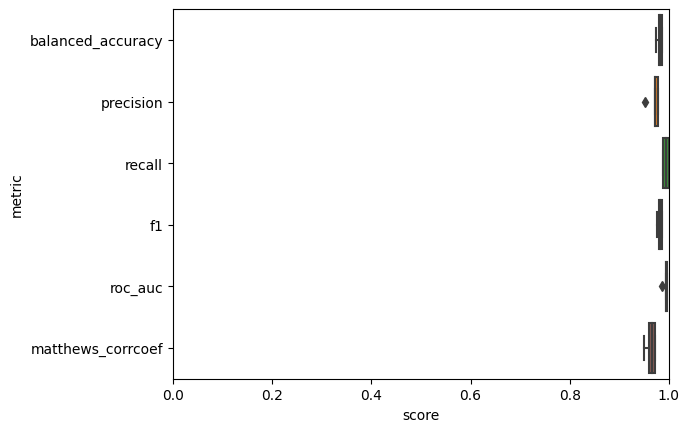

In [22]:
cv_scores = phenotype_predictor.cross_validate_kfold(n_splits=5)
phenotype_predictor.plot_cross_validation(cv_scores)

## SHAP values


In [23]:
import shap

In [24]:
explainer = shap.Explainer(clf)

In [25]:
shap_values = explainer.shap_values(data["X_train"])

In [26]:
shap_values.shape, data["X_train"].shape

((1762, 2599), (1762, 2599))

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


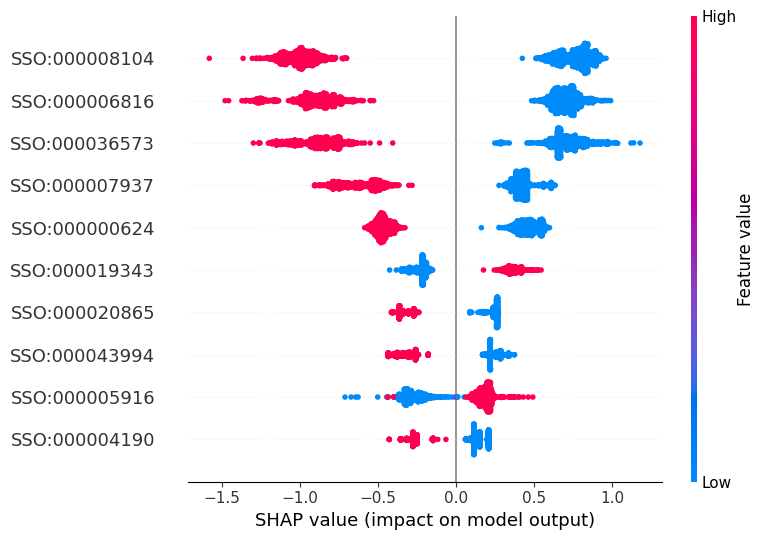

In [27]:
shap.summary_plot(shap_values, data["X_train"], max_display=10)

In [28]:
rast_sso_dict["SSO:000008104"], rast_sso_dict["SSO:000006816"], rast_sso_dict[
    "SSO:000007937"
],

('TonB-dependent receptor',
 "Pyridoxine 5'-phosphate synthase (EC 2.6.99.2)",
 "Tetraacyldisaccharide 4'-kinase (EC 2.7.1.130)")

TonB is an outer membrane protein
Tetraaacyyldisaccharide 4'-kinase is an enzyme precursor for LPS (gram neg outermembrane)

## Feature elimination + Hyperparameter tuning

In [29]:
X_train = data["X_train"]
y_train = data["y_train"]
X_test = data["X_test"]
y_test = data["y_test"]
scoring=(
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "matthews_corrcoef",
)

In [30]:
shap_importances = np.abs(shap_values).mean(0)
importance_df = pd.DataFrame({"feature": X_train.columns, "importance": shap_importances})
importance_df.sort_values(by="importance", ascending=False, inplace=True)
feature_list = importance_df["feature"].tolist()[:1000]

In [31]:
import optuna
from sklearn.model_selection import cross_validate

In [32]:
def objective(trial):
    k = trial.suggest_int('k', 100, X_train.shape[1], step=100)
    params = {
        "iterations": trial.suggest_int("iterations", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        "depth": trial.suggest_int("depth", 1, 10),
    }
    model_full = CatBoostClassifier(**params, random_state=random_state, verbose=0)
    model_full.fit(X_train, y_train)
    explainer = shap.Explainer(model_full)
    shap_values = explainer.shap_values(X_test)
    shap_importances = np.abs(shap_values).mean(0)
    importance_df = pd.DataFrame({"feature": X_train.columns, "importance": shap_importances})
    importance_df.sort_values(by="importance", ascending=False, inplace=True)
    feature_list = importance_df["feature"].tolist()[:k]
    # update the model
    model = CatBoostClassifier(**params, random_state=random_state, verbose=0)
    model.fit(X_train[feature_list], y_train)
    cv_score = cross_validate(model, X_train[feature_list], y_train, scoring=scoring, cv=5, n_jobs=-1)
    return cv_score["test_matthews_corrcoef"].mean()

In [33]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100, show_progress_bar=True)

[I 2023-09-06 17:49:10,679] A new study created in memory with name: no-name-fcf9710f-4d73-4ad5-b78f-be18005b66f8


  0%|          | 0/100 [00:00<?, ?it/s]

The distribution is specified by [100, 2599] and step=100, but the range is not divisible by `step`. It will be replaced by [100, 2500].


[I 2023-09-06 17:52:54,261] Trial 0 finished with value: 0.9651471186778597 and parameters: {'k': 200, 'iterations': 513, 'learning_rate': 0.07235882949828143, 'depth': 10}. Best is trial 0 with value: 0.9651471186778597.


The distribution is specified by [100, 2599] and step=100, but the range is not divisible by `step`. It will be replaced by [100, 2500].


...

[I 2023-09-06 19:03:51,170] Trial 97 finished with value: 0.9740853892027677 and parameters: {'k': 100, 'iterations': 450, 'learning_rate': 0.1205406166355849, 'depth': 1}. Best is trial 92 with value: 0.9751820318758535.


The distribution is specified by [100, 2599] and step=100, but the range is not divisible by `step`. It will be replaced by [100, 2500].


[I 2023-09-06 19:03:54,001] Trial 98 finished with value: 0.9740396463549276 and parameters: {'k': 100, 'iterations': 447, 'learning_rate': 0.15267345701045998, 'depth': 1}. Best is trial 92 with value: 0.9751820318758535.


The distribution is specified by [100, 2599] and step=100, but the range is not divisible by `step`. It will be replaced by [100, 2500].


[I 2023-09-06 19:03:56,628] Trial 99 finished with value: 0.9729430036818417 and parameters: {'k': 100, 'iterations': 427, 'learning_rate': 0.1505628332365165, 'depth': 1}. Best is trial 92 with value: 0.9751820318758535.


In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
import pickle

with open("grampos_study.pkl", "wb") as f:
    pickle.dump(study, f)